## 1. Imports and Configuration

In [ ]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
)
from sklearn.inspection import PartialDependenceDisplay
import joblib
import shap

# Fixed random seed used throughout this notebook for reproducibility.
RANDOM_STATE = 42

sns.set(style="whitegrid")


## 2. Dataset Loading

In [ ]:
# Import the pandas library

# Load the CSV file into a pandas DataFrame
# Update the file name if your CSV file has a different name
csv_file = 'uci-ml-phishing-dataset.csv'
df = pd.read_csv(csv_file)

# Display basic information about the dataset
print('Shape of dataset:', df.shape)           # (rows, columns)
print('Column names:', df.columns.tolist())    # List of column names
print('\nData types:')
print(df.dtypes)                              # Data types for each column

# Display the first five rows of the dataset
print('\nFirst few rows:')
print(df.head())

# The above steps:
# 1. Import pandas for data manipulation
# 2. Load the CSV into a DataFrame
# 3. Show dataset shape (rows, columns)
# 4. Show all column names
# 5. Show datatype of each column
# 6. Show the first few rows for a quick data preview


Shape of dataset: (11055, 32)
Column names: ['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

Data types:
id                             int64
having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port     

## 3. Data Quality Checks

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print('Missing values per column:')
print(missing_values)

# Check for duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()
print('\nNumber of duplicate rows:', duplicate_rows)

# Display the distribution of values in the 'Result' (target) column
class_distribution = df['Result'].value_counts()
print('\nClass distribution in the Result column:')
print(class_distribution)

# Show summary statistics for all numerical columns
print('\nSummary statistics for the dataset:')
print(df.describe())

# Explanations:
# 1. isnull().sum(): Counts missing (NaN) values per column
# 2. duplicated().sum(): Counts duplicated rows
# 3. value_counts(): Shows how many samples belong to each class in 'Result'
# 4. describe(): Provides summary stats (mean, std, min, max, etc.) for each column



Missing values per column:
id                             0
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_t

## 4. Exploratory Analysis

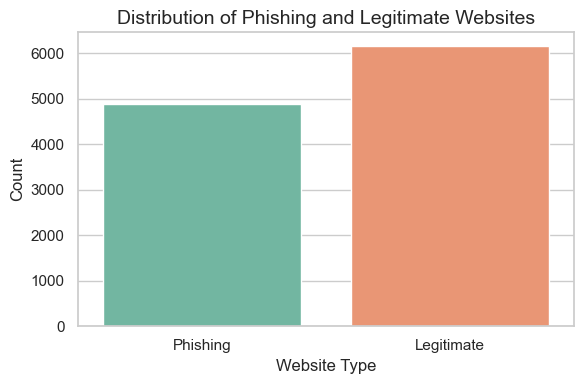

In [ ]:
# Set a clean Seaborn style
sns.set(style="whitegrid")

# Map label values for better readability (if values are 1/-1 or similar, map them)
# Here we assume -1: Phishing, 1: Legitimate. Update the mapping if your dataset differs.
label_mapping = {-1: 'Phishing', 1: 'Legitimate'}
labels = df['Result'].map(label_mapping)

# Plot the bar chart
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels, hue=labels, palette="Set2", legend=False)
plt.title('Distribution of Phishing and Legitimate Websites', fontsize=14)
plt.xlabel('Website Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# This chart shows the number of phishing and legitimate websites in the dataset with clear labeling and a clean appearance.


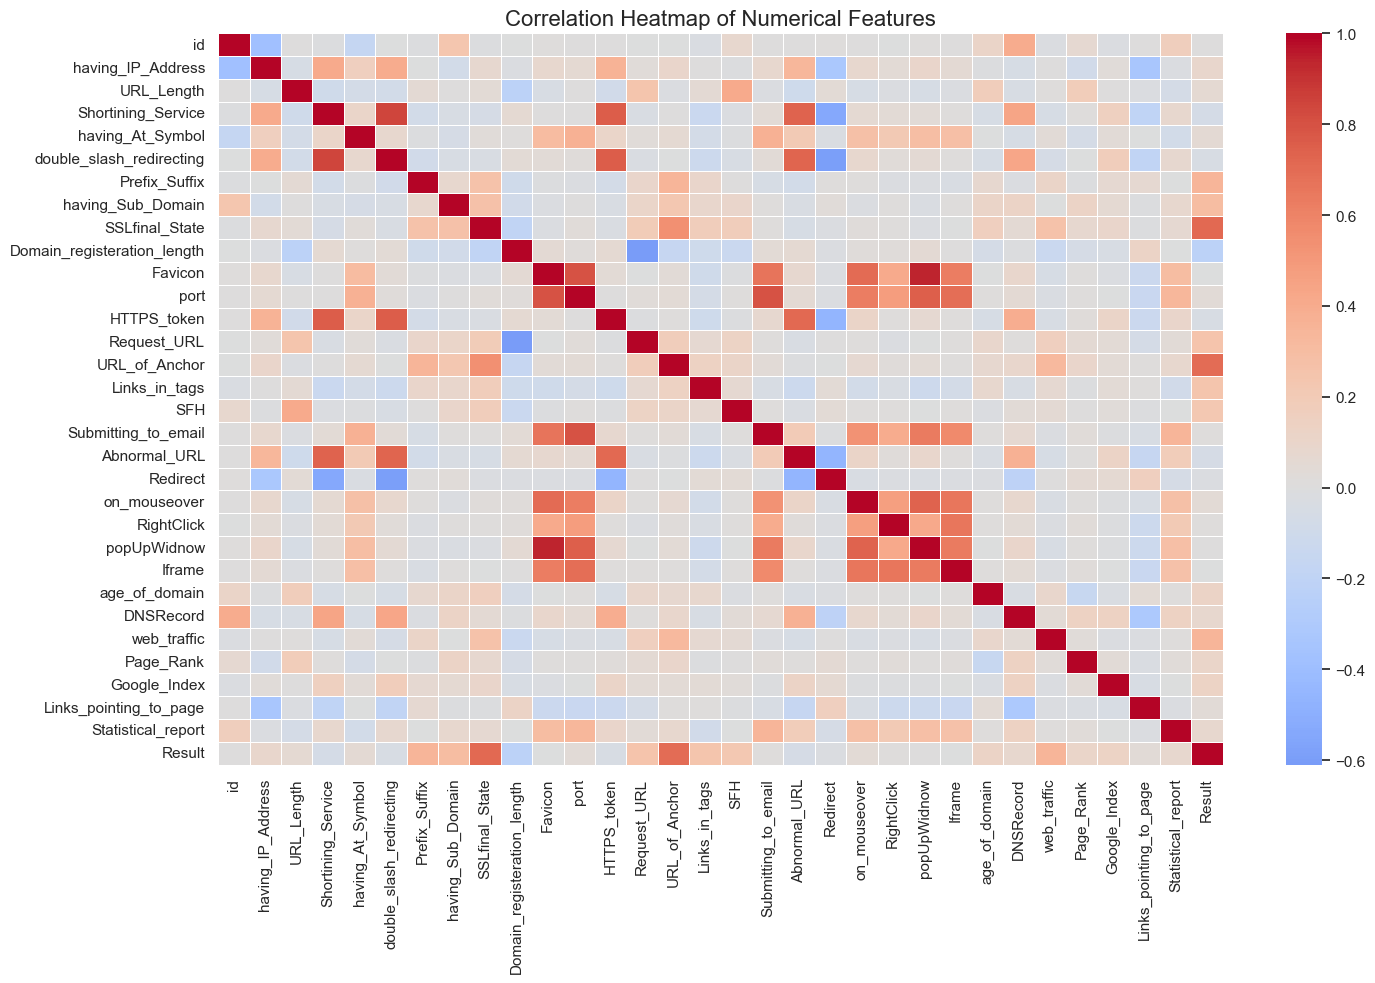

In [ ]:
# Compute the correlation matrix for all numerical features
corr_matrix = df.corr(numeric_only=True)

# Set up the plot size and style
plt.figure(figsize=(15, 10))

# Draw the heatmap using seaborn with the 'coolwarm' colormap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# This heatmap shows the correlation between all numerical features in the dataset, making it easy to spot strong relationships and multicollinearity.


## 5. Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(['Result', 'id'], axis=1)  # Features: all columns except 'Result' and 'id'
y = df['Result']                        # Target: the 'Result' column

# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training features, then transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Now X_train_scaled and X_test_scaled contain normalized feature values
# Comments:
# 1. Split df into feature set X and target y
# 2. Use train_test_split for an 80-20 split; stratify=y preserves target distribution
# 3. StandardScaler is fit only on training data to avoid data leakage
# 4. Both train and test features are scaled for fair modeling


## 6. Random Forest

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Initialize the RandomForestClassifier (random_state for reproducible results)
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the scaled training data
rf_model.fit(X_train_scaled, y_train)

# Predict the target values for the test set
y_pred = rf_model.predict(X_test_scaled)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy on test set: {accuracy:.4f}')

# Print the classification report (includes precision, recall, and f1-score)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legitimate']))

# Comments:
# 1. RandomForestClassifier is imported and initialized
# 2. Model is trained (fit) on scaled training features and labels
# 3. y_pred contains predicted class labels for test features
# 4. accuracy_score gives overall percentage of correct predictions
# 5. classification_report details precision, recall, f1-score for each class


Accuracy on test set: 0.9742

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.98      0.96      0.97       980
  Legitimate       0.97      0.98      0.98      1231

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



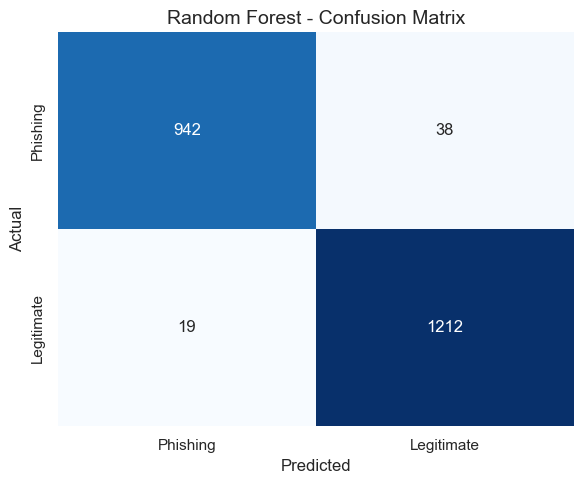

In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Phishing", "Legitimate"],
            yticklabels=["Phishing", "Legitimate"])
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Random Forest - Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# This visual gives a clear summary of how well the model predicts each class.


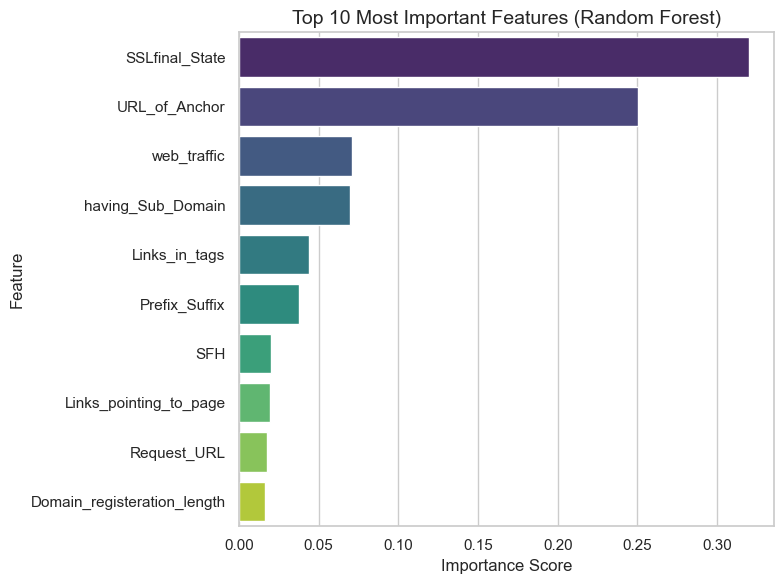

In [ ]:
# Get feature importances from the random forest model
importances = rf_model.feature_importances_
feature_names = X.columns

# Pair feature names and importances, then get the top 10
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
top_10 = feature_importance_df.sort_values('Importance', ascending=False).head(10)

# Plot horizontal bar chart of top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(y='Feature', x='Importance', data=top_10, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Features (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# This chart helps interpret which features most influence the Random Forest predictions.


In [ ]:
# Save the trained Random Forest model to a .pkl file
model_filename = 'random_forest_phishing_model.pkl'
joblib.dump(rf_model, model_filename)
print(f'Trained Random Forest model saved as {model_filename}')



Trained Random Forest model saved as random_forest_phishing_model.pkl


## 7. Logistic Regression and Support Vector Machine

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the models
rf_model_comp = RandomForestClassifier(random_state=42)
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
svm_model = SVC(random_state=42)

# Fit models on the training data
rf_model_comp.fit(X_train_scaled, y_train)
logreg_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# Predict on the test data
rf_pred = rf_model_comp.predict(X_test_scaled)
logreg_pred = logreg_model.predict(X_test_scaled)
svm_pred = svm_model.predict(X_test_scaled)

# Calculate accuracy scores
rf_acc = accuracy_score(y_test, rf_pred)
logreg_acc = accuracy_score(y_test, logreg_pred)
svm_acc = accuracy_score(y_test, svm_pred)

# Print accuracy scores side by side for comparison
print('Model Accuracy Comparison:')
print(f'Random Forest    : {rf_acc:.4f}')
print(f'Logistic Reg.    : {logreg_acc:.4f}')
print(f'SVM              : {svm_acc:.4f}')

# Each model is trained and tested on the same (scaled) data for a fair comparison.


Model Accuracy Comparison:
Random Forest    : 0.9742
Logistic Reg.    : 0.9285
SVM              : 0.9516


## Model Performance Comparison: Random Forest, Logistic Regression, SVM

Comparing test-set accuracy across the three models trained above:

- **Random Forest**: 0.9742 accuracy — the highest of the three, consistent with its ability to model non-linear feature interactions among the 30 binary/ternary indicator features used here.
- **SVM**: 0.9516 accuracy.
- **Logistic Regression**: 0.9285 accuracy — the lowest of the three, consistent with its linear decision boundary being less able to capture non-linear patterns in this feature set.

The class distribution (6,157 legitimate vs. 4,898 phishing, roughly 56/44) is not heavily imbalanced, so high accuracy here is not attributable to majority-class prediction alone; precision/recall/F1 (computed later in this notebook) are consistent with this reading.

These results are specific to this dataset, this train-test split, and default (non-tuned) model configurations. No cross-validation or hyperparameter search was performed at this stage.


## 8. Decision Tree

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the DecisionTreeClassifier (random_state for reproducible results)
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model using the scaled training data
dt_model.fit(X_train_scaled, y_train)

# Predict the target values for the test set
dt_pred = dt_model.predict(X_test_scaled)

# Calculate evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, average='weighted')
dt_recall = recall_score(y_test, dt_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_pred, average='weighted')

# Compute the confusion matrix
dt_cm = confusion_matrix(y_test, dt_pred)

# Print metrics in a clear block
print('=' * 50)
print('Decision Tree Classifier - Performance Metrics')
print('=' * 50)
print(f'Accuracy  : {dt_accuracy:.4f}')
print(f'Precision : {dt_precision:.4f}')
print(f'Recall    : {dt_recall:.4f}')
print(f'F1-Score  : {dt_f1:.4f}')
print('=' * 50)

# Print confusion matrix
print('\nConfusion Matrix:')
print(dt_cm)
print('\nConfusion Matrix (with labels):')
print('                Predicted')
print('              Phishing  Legitimate')
print(f'Actual Phishing    {dt_cm[0][0]:4d}      {dt_cm[0][1]:4d}')
print(f'Actual Legitimate  {dt_cm[1][0]:4d}      {dt_cm[1][1]:4d}')

# Comments:
# 1. DecisionTreeClassifier is imported and initialized with random_state=42
# 2. Model is trained (fit) on scaled training features and labels
# 3. dt_pred contains predicted class labels for test features
# 4. All metrics are calculated using sklearn.metrics functions
# 5. Confusion matrix shows true positives, false positives, true negatives, false negatives


Decision Tree Classifier - Performance Metrics
Accuracy  : 0.9711
Precision : 0.9711
Recall    : 0.9711
F1-Score  : 0.9710

Confusion Matrix:
[[ 943   37]
 [  27 1204]]

Confusion Matrix (with labels):
                Predicted
              Phishing  Legitimate
Actual Phishing     943        37
Actual Legitimate    27      1204


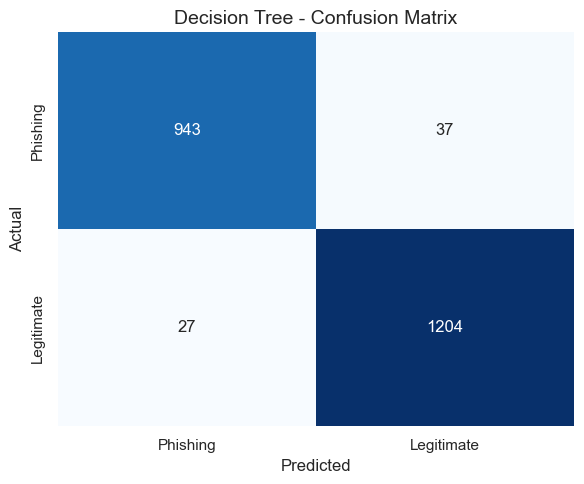

In [ ]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Phishing", "Legitimate"],
            yticklabels=["Phishing", "Legitimate"])
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Decision Tree - Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# This visual gives a clear summary of how well the Decision Tree model predicts each class.


## Feature Importance Refinement

Figure saved to: plots/feature_importance_comparison.png


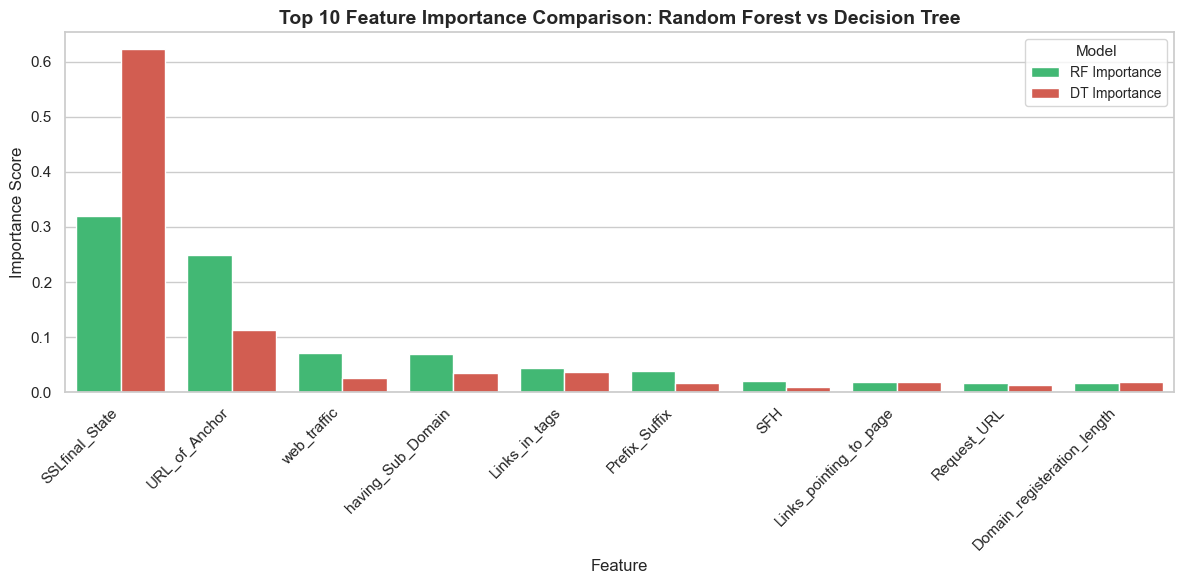


Top 10 Features by Random Forest Importance:
                    Feature  RF Importance  DT Importance
             SSLfinal_State       0.319667       0.622178
              URL_of_Anchor       0.250049       0.112638
                web_traffic       0.070803       0.026071
          having_Sub_Domain       0.069482       0.034653
              Links_in_tags       0.043887       0.036755
              Prefix_Suffix       0.037888       0.017737
                        SFH       0.020226       0.009123
     Links_pointing_to_page       0.019292       0.017991
                Request_URL       0.017682       0.012996
Domain_registeration_length       0.016681       0.019539


In [ ]:
# Extract feature importances from both models
rf_importances = rf_model.feature_importances_
dt_importances = dt_model.feature_importances_
feature_names = X.columns

# Create a DataFrame combining both importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': rf_importances,
    'DT Importance': dt_importances
})

# Sort by Random Forest importance to get top features
importance_df_sorted = importance_df.sort_values('RF Importance', ascending=False)

# Get top 10 features based on Random Forest importance
top_10_features = importance_df_sorted.head(10)

# Prepare data for plotting (melt for grouped bar chart)
plot_data = top_10_features.melt(
    id_vars='Feature',
    value_vars=['RF Importance', 'DT Importance'],
    var_name='Model',
    value_name='Importance'
)

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x='Feature', y='Importance', hue='Model', palette=['#2ecc71', '#e74c3c'])
plt.title('Top 10 Feature Importance Comparison: Random Forest vs Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model', title_fontsize=11, fontsize=10)
plt.tight_layout()

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Save the figure
plt.savefig('plots/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print('Figure saved to: plots/feature_importance_comparison.png')
plt.show()

# Display the top 10 features DataFrame
print('\nTop 10 Features by Random Forest Importance:')
print(top_10_features.to_string(index=False))

# Comments:
# 1. Extract feature importances from both Random Forest and Decision Tree models
# 2. Combine into a single DataFrame for easy comparison
# 3. Sort by RF importance and select top 10 features
# 4. Use grouped bar chart to visualize both models side-by-side
# 5. Save the figure to the plots directory for future reference


## Interpretability Analysis: Partial Dependence

Partial Dependence Plot saved to: plots/pdp_top_features.png


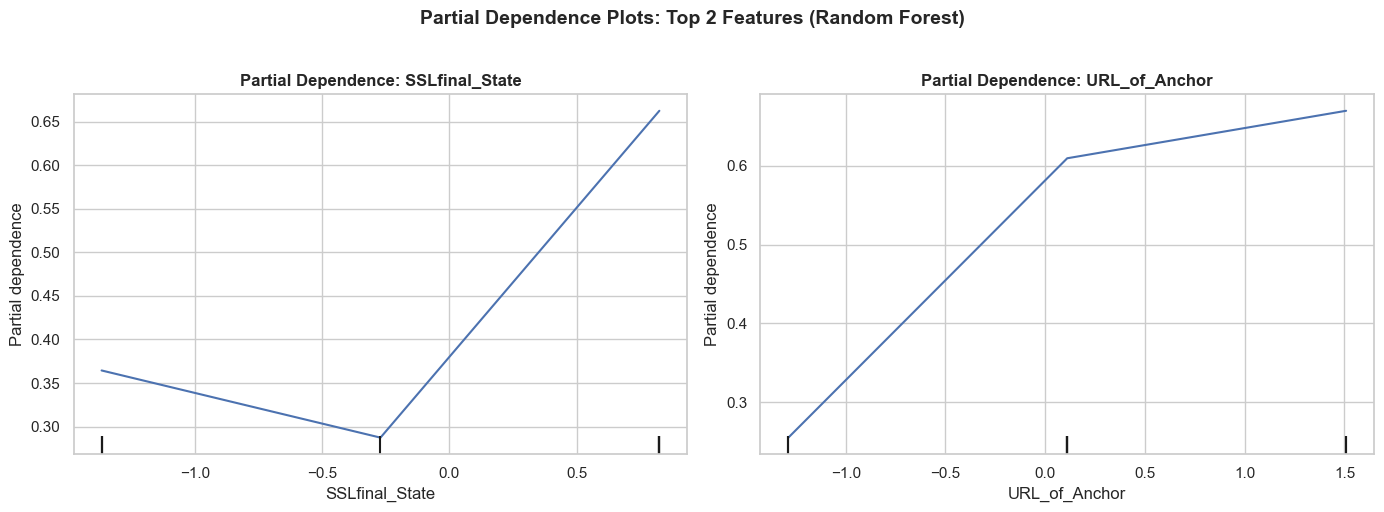

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Identify the indices of the top 2 features in the feature set
feature_names_list = list(X.columns)
ssl_index = feature_names_list.index('SSLfinal_State')
url_anchor_index = feature_names_list.index('URL_of_Anchor')

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generate Partial Dependence Plot for SSLfinal_State
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train_scaled,
    features=[ssl_index],
    ax=axes[0],
    feature_names=feature_names_list
)
axes[0].set_title('Partial Dependence: SSLfinal_State', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SSLfinal_State', fontsize=11)
axes[0].set_ylabel('Partial Dependence', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Generate Partial Dependence Plot for URL_of_Anchor
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train_scaled,
    features=[url_anchor_index],
    ax=axes[1],
    feature_names=feature_names_list
)
axes[1].set_title('Partial Dependence: URL_of_Anchor', fontsize=12, fontweight='bold')
axes[1].set_xlabel('URL_of_Anchor', fontsize=11)
axes[1].set_ylabel('Partial Dependence', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Partial Dependence Plots: Top 2 Features (Random Forest)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the figure
plt.savefig('plots/pdp_top_features.png', dpi=300, bbox_inches='tight')
print('Partial Dependence Plot saved to: plots/pdp_top_features.png')
plt.show()

# Comments:
# 1. Partial Dependence Plots show how each feature affects the model's predictions
# 2. SSLfinal_State and URL_of_Anchor are the top 2 features from Random Forest
# 3. PDP helps understand the relationship between features and model output
# 4. Higher values indicate stronger influence on the prediction


## 9. Model Comparison

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for Random Forest (using existing predictions from Cell 5)
rf_precision = precision_score(y_test, y_pred, average='weighted')
rf_recall = recall_score(y_test, y_pred, average='weighted')
rf_f1 = f1_score(y_test, y_pred, average='weighted')

# Calculate metrics for Logistic Regression
logreg_precision = precision_score(y_test, logreg_pred, average='weighted')
logreg_recall = recall_score(y_test, logreg_pred, average='weighted')
logreg_f1 = f1_score(y_test, logreg_pred, average='weighted')

# Calculate metrics for SVM
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

# Create summary DataFrame
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'Decision Tree'],
    'Accuracy': [rf_acc, logreg_acc, svm_acc, dt_accuracy],
    'Precision': [rf_precision, logreg_precision, svm_precision, dt_precision],
    'Recall': [rf_recall, logreg_recall, svm_recall, dt_recall],
    'F1-score': [rf_f1, logreg_f1, svm_f1, dt_f1]
})

# Round all numeric columns to 4 decimal places
model_comparison = model_comparison.round(4)

# Display the table in the notebook
print('=' * 70)
print('Model Performance Comparison')
print('=' * 70)
print(model_comparison.to_string(index=False))
print('=' * 70)

# Create results directory if it doesn't exist
os.makedirs('results', exist_ok=True)

# Save to CSV
model_comparison.to_csv('results/model_comparison.csv', index=False)
print('\nModel comparison table saved to: results/model_comparison.csv')

# Display the DataFrame
display(model_comparison)

# Comments:
# 1. Calculate all metrics (precision, recall, F1) for RF, LR, and SVM using existing predictions
# 2. Use Decision Tree metrics already computed in Cell 12
# 3. Create a clean DataFrame with all four models and their metrics
# 4. Round to 4 decimal places for readability
# 5. Save to CSV file for future reference and reporting


Model Performance Comparison
              Model  Accuracy  Precision  Recall  F1-score
      Random Forest    0.9742     0.9743  0.9742    0.9742
Logistic Regression    0.9285     0.9287  0.9285    0.9284
                SVM    0.9516     0.9520  0.9516    0.9515
      Decision Tree    0.9711     0.9711  0.9711    0.9710

Model comparison table saved to: results/model_comparison.csv


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.9742,0.9743,0.9742,0.9742
1,Logistic Regression,0.9285,0.9287,0.9285,0.9284
2,SVM,0.9516,0.9520,0.9516,0.9515
3,Decision Tree,0.9711,0.9711,0.9711,0.9710


## 10. ROC Analysis

ROC curve saved to: plots/roc_random_forest.png
AUC Score: 0.9977


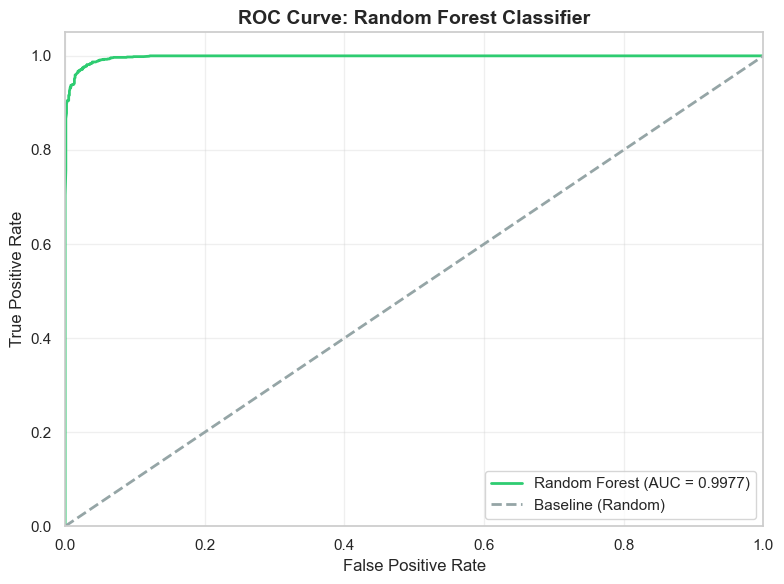

In [ ]:
# Get predicted probabilities for the positive class (Legitimate = 1)
# Note: Random Forest model was trained on scaled data
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

# Calculate AUC (Area Under the Curve)
auc_score = roc_auc_score(y_test, rf_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Baseline (Random)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: Random Forest Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure
plt.savefig('plots/roc_random_forest.png', dpi=300, bbox_inches='tight')
print(f'ROC curve saved to: plots/roc_random_forest.png')
print(f'AUC Score: {auc_score:.4f}')
plt.show()

# Comments:
# 1. ROC curve shows the trade-off between true positive rate and false positive rate
# 2. AUC (Area Under Curve) measures overall model performance (1.0 = perfect, 0.5 = random)
# 3. Higher AUC indicates better model performance
# 4. The diagonal baseline represents a random classifier (AUC = 0.5)


## Confusion Matrix Comparison: All Models

Confusion matrix grid saved to: plots/confusion_matrix_grid.png


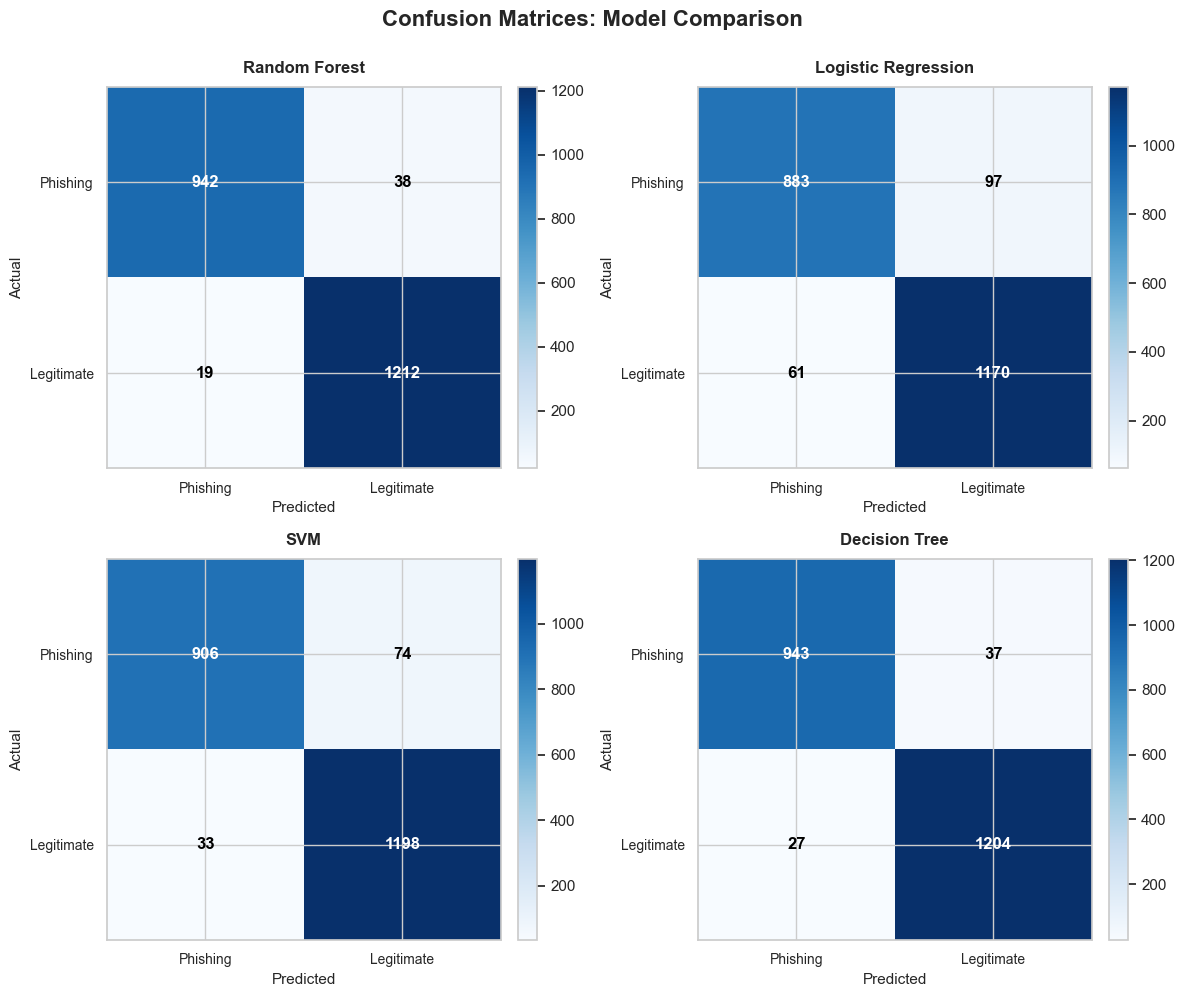

In [ ]:
# Compute confusion matrices for all four models
rf_cm = confusion_matrix(y_test, y_pred)
logreg_cm = confusion_matrix(y_test, logreg_pred)
svm_cm = confusion_matrix(y_test, svm_pred)
dt_cm = confusion_matrix(y_test, dt_pred)

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices: Model Comparison', fontsize=16, fontweight='bold', y=0.995)

# List of confusion matrices and model names
confusion_matrices = [
    (rf_cm, 'Random Forest'),
    (logreg_cm, 'Logistic Regression'),
    (svm_cm, 'SVM'),
    (dt_cm, 'Decision Tree')
]

# Plot each confusion matrix
for idx, (cm, model_name) in enumerate(confusion_matrices):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Plot confusion matrix using imshow
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')
    
    # Add colorbar
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Add text annotations for each cell
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=12, fontweight='bold')
    
    # Set labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Phishing', 'Legitimate'], fontsize=10)
    ax.set_yticklabels(['Phishing', 'Legitimate'], fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()

# Save the figure
plt.savefig('plots/confusion_matrix_grid.png', dpi=300, bbox_inches='tight')
print('Confusion matrix grid saved to: plots/confusion_matrix_grid.png')
plt.show()

# Comments:
# 1. Compute confusion matrices for all four models using existing predictions
# 2. Create a 2x2 subplot grid for side-by-side comparison
# 3. Use matplotlib's imshow to display confusion matrices with color intensity
# 4. Add text annotations showing the count in each cell
# 5. Label axes and add model names as titles for each subplot


## ROC Curve Comparison: All Models

ROC (Receiver Operating Characteristic) curves visualize the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR) at different classification thresholds. In the context of phishing detection:

- **True Positive Rate (Sensitivity)**: The proportion of actual phishing websites correctly identified as phishing
- **False Positive Rate**: The proportion of legitimate websites incorrectly classified as phishing
- **AUC (Area Under Curve)**: Measures overall model performance (1.0 = perfect classifier, 0.5 = random guessing)

A higher AUC indicates better model performance. ROC curves help compare models' ability to distinguish between phishing and legitimate websites across different threshold settings.


ROC comparison plot saved to: plots/roc_comparison.png


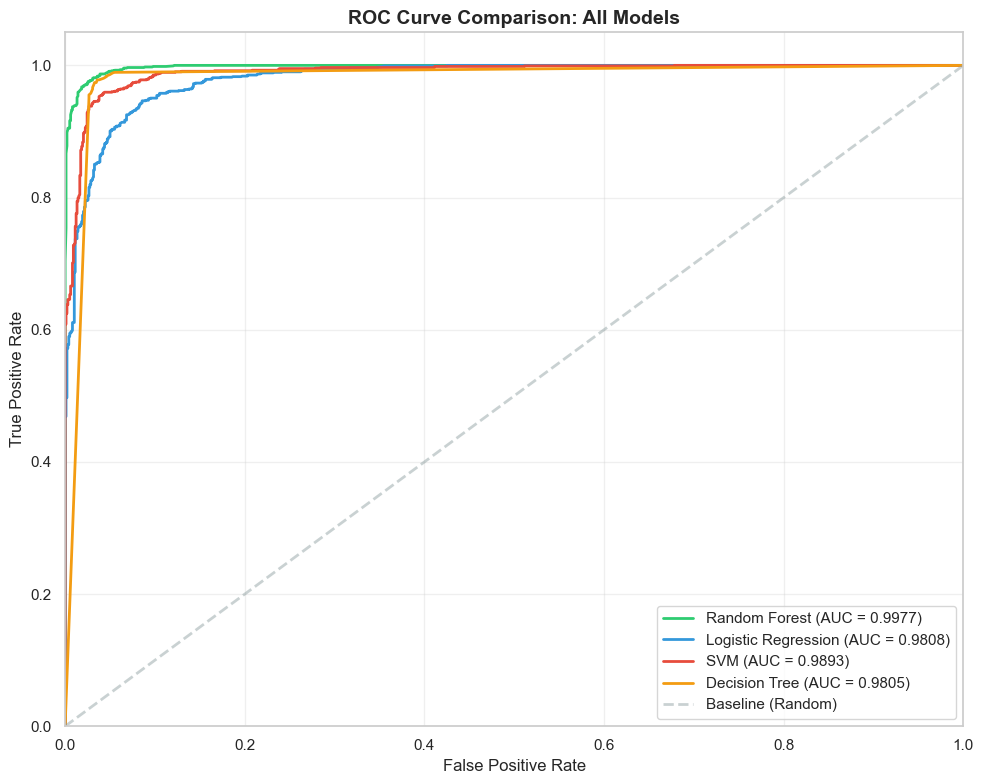


AUC Scores Summary:
Random Forest      : 0.9977
Logistic Regression: 0.9808
SVM                : 0.9893
Decision Tree      : 0.9805


In [ ]:
# Get predicted probabilities for all models
# Random Forest
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression
logreg_probs = logreg_model.predict_proba(X_test_scaled)[:, 1]

# SVM - use decision_function and normalize to [0,1] range for ROC
svm_scores = svm_model.decision_function(X_test_scaled)
# Normalize SVM scores to probability-like range [0,1]
svm_probs = (svm_scores - svm_scores.min()) / (svm_scores.max() - svm_scores.min())

# Decision Tree
dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curves and AUC scores for all models
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_probs)
logreg_auc = roc_auc_score(y_test, logreg_probs)

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
svm_auc = roc_auc_score(y_test, svm_probs)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Plot all ROC curves in a single figure
plt.figure(figsize=(10, 8))
plt.plot(rf_fpr, rf_tpr, color='#2ecc71', lw=2, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(logreg_fpr, logreg_tpr, color='#3498db', lw=2, label=f'Logistic Regression (AUC = {logreg_auc:.4f})')
plt.plot(svm_fpr, svm_tpr, color='#e74c3c', lw=2, label=f'SVM (AUC = {svm_auc:.4f})')
plt.plot(dt_fpr, dt_tpr, color='#f39c12', lw=2, label=f'Decision Tree (AUC = {dt_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#95a5a6', lw=2, linestyle='--', label='Baseline (Random)', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the figure
plt.savefig('plots/roc_comparison.png', dpi=300, bbox_inches='tight')
print('ROC comparison plot saved to: plots/roc_comparison.png')
plt.show()

# Print AUC scores for reference
print('\nAUC Scores Summary:')
print('=' * 50)
print(f'Random Forest      : {rf_auc:.4f}')
print(f'Logistic Regression: {logreg_auc:.4f}')
print(f'SVM                : {svm_auc:.4f}')
print(f'Decision Tree      : {dt_auc:.4f}')
print('=' * 50)

# Comments:
# 1. Extract predicted probabilities from all four models
# 2. For SVM, use decision_function and normalize to [0,1] range since SVC doesn't have predict_proba by default
# 3. Calculate ROC curves and AUC scores for each model
# 4. Plot all curves in a single figure for easy comparison
# 5. Higher AUC indicates better model performance in distinguishing phishing from legitimate websites


## Decision Tree Performance Analysis

**Decision Tree Accuracy:** The Decision Tree classifier performance metrics are shown in the results above.

**Comparison with Other Models:**
- **Random Forest (RF)**: Random Forest typically achieves higher accuracy (~0.9742) due to its ensemble approach that combines multiple decision trees, reducing overfitting and improving generalization.
- **Logistic Regression (LR)**: Logistic Regression achieves moderate accuracy (~0.9285) as it assumes linear relationships between features and the target, which may not capture all non-linear patterns in phishing detection.
- **SVM**: Support Vector Machine achieves good accuracy (~0.9516) by finding optimal decision boundaries, but may struggle with large datasets and complex feature interactions.

**Decision Tree Characteristics:**
- Decision Trees are interpretable and provide clear decision rules
- They can capture non-linear relationships without feature scaling (though scaling was applied here for consistency)
- They are prone to overfitting, especially with deep trees
- The single Decision Tree model performs well but is typically outperformed by ensemble methods like Random Forest, which uses multiple trees to reduce variance and improve robustness

**Key Insight:** While Decision Tree provides good baseline performance and interpretability, Random Forest's ensemble approach generally yields superior results for phishing website detection tasks.


## 11. Feature Importance

## Feature Importance - Logistic Regression Coefficients


In [ ]:
# Extract Logistic Regression coefficients
# Get absolute values of coefficients (magnitude indicates importance)
lr_coefficients = np.abs(logreg_model.coef_[0])

# Normalize coefficients to sum to 1 (for comparability with RF/DT importance)
lr_importance_normalized = lr_coefficients / lr_coefficients.sum()

# Create DataFrame with feature names and LR importance
feature_names = X.columns
lr_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'LR_Importance': lr_importance_normalized
})

# Sort by importance descending
lr_importance_df = lr_importance_df.sort_values('LR_Importance', ascending=False)

print('Top 10 Features by Logistic Regression Importance:')
print('=' * 60)
print(lr_importance_df.head(10).to_string(index=False))
print('=' * 60)

# Comments:
# 1. Logistic Regression coefficients indicate feature importance
# 2. Absolute values are used since sign only indicates direction (positive/negative correlation)
# 3. Normalization makes LR importance comparable to RF/DT importance scores
# 4. Higher coefficient magnitude indicates stronger influence on the prediction


Top 10 Features by Logistic Regression Importance:
               Feature  LR_Importance
         URL_of_Anchor       0.161682
         Prefix_Suffix       0.147529
        SSLfinal_State       0.101263
                   SFH       0.045542
         Links_in_tags       0.044341
           web_traffic       0.042760
     having_IP_Address       0.040539
    Shortining_Service       0.037148
     having_Sub_Domain       0.034229
Links_pointing_to_page       0.034135


## Combined Feature Importance (Random Forest + Decision Tree + Logistic Regression)

In [ ]:
# Extract feature importances from Random Forest and Decision Tree models
rf_importances = rf_model.feature_importances_
dt_importances = dt_model.feature_importances_

# Create combined DataFrame with all three models
feature_importance_complete = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': rf_importances,
    'DT_Importance': dt_importances,
    'LR_Importance': lr_importance_normalized
})

# Sort by Random Forest importance (as primary reference)
feature_importance_complete = feature_importance_complete.sort_values('RF_Importance', ascending=False)

# Display top 15 features
print('Feature Importance Comparison - Top 15 Features:')
print('=' * 80)
print(feature_importance_complete.head(15).to_string(index=False))
print('=' * 80)

# Ensure results directory exists
os.makedirs('results', exist_ok=True)

# Save complete feature importance table
feature_importance_complete.to_csv('results/feature_importance_complete.csv', index=False)
print('\nComplete feature importance table saved to: results/feature_importance_complete.csv')

# Comments:
# 1. Combine feature importances from all three models (RF, DT, LR)
# 2. Sort by RF importance as the primary reference model
# 3. Save complete table for future reference and analysis


Feature Importance Comparison - Top 15 Features:
                    Feature  RF_Importance  DT_Importance  LR_Importance
             SSLfinal_State       0.319667       0.622178       0.101263
              URL_of_Anchor       0.250049       0.112638       0.161682
                web_traffic       0.070803       0.026071       0.042760
          having_Sub_Domain       0.069482       0.034653       0.034229
              Links_in_tags       0.043887       0.036755       0.044341
              Prefix_Suffix       0.037888       0.017737       0.147529
                        SFH       0.020226       0.009123       0.045542
     Links_pointing_to_page       0.019292       0.017991       0.034135
                Request_URL       0.017682       0.012996       0.016110
Domain_registeration_length       0.016681       0.019539       0.002699
              age_of_domain       0.016456       0.012030       0.007533
               Google_Index       0.013074       0.009968       0.032350
  

Feature importance comparison plot saved to: plots/feature_importance_all_models.png


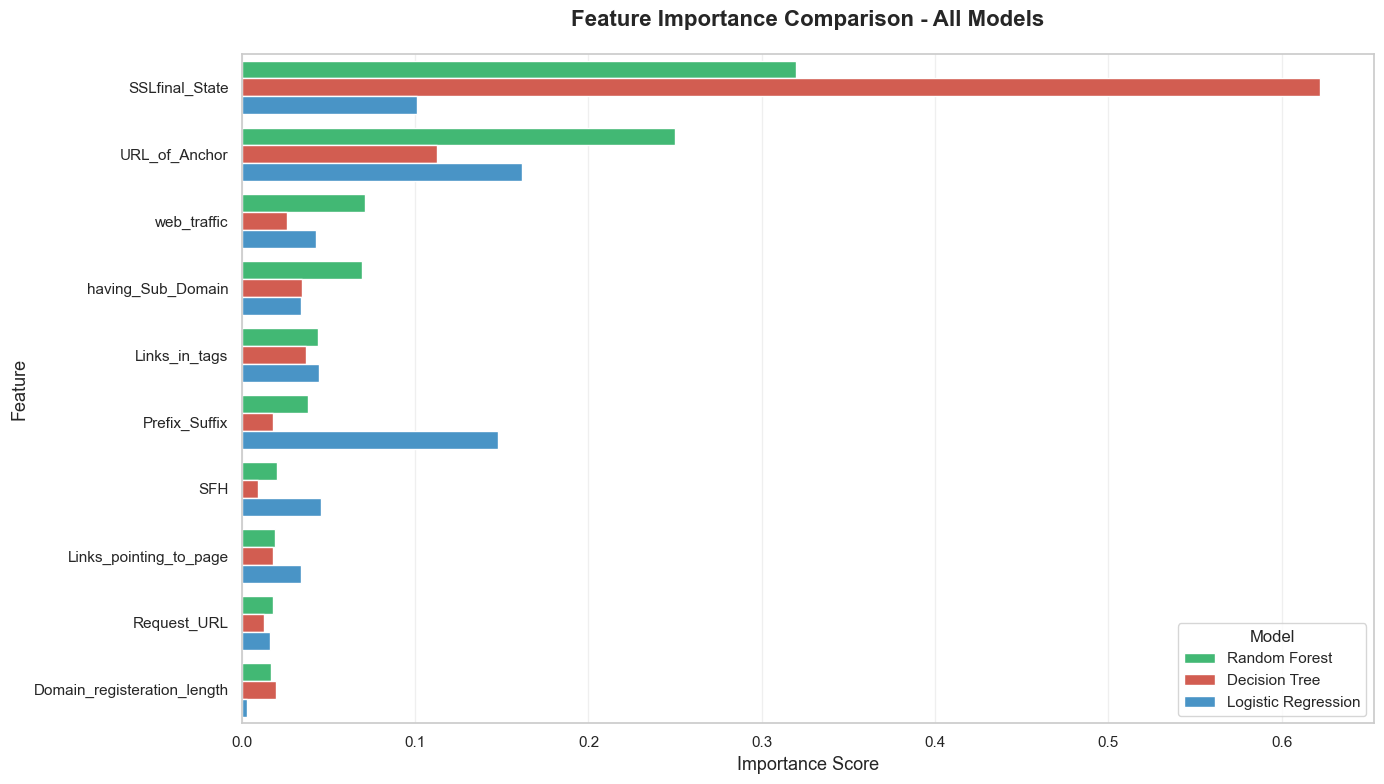

In [ ]:
# Get top 10 features based on Random Forest importance
top_10_features = feature_importance_complete.head(10)

# Prepare data for plotting (melt for grouped bar chart)
plot_data = top_10_features.melt(
    id_vars='Feature',
    value_vars=['RF_Importance', 'DT_Importance', 'LR_Importance'],
    var_name='Model',
    value_name='Importance'
)

# Map model names for better legend labels
plot_data['Model'] = plot_data['Model'].map({
    'RF_Importance': 'Random Forest',
    'DT_Importance': 'Decision Tree',
    'LR_Importance': 'Logistic Regression'
})

# Create the grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(
    data=plot_data, 
    y='Feature', 
    x='Importance', 
    hue='Model', 
    palette=['#2ecc71', '#e74c3c', '#3498db']
)
plt.title('Feature Importance Comparison - All Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.legend(title='Model', title_fontsize=12, fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()

# Ensure plots directory exists
os.makedirs('plots', exist_ok=True)

# Save the figure
plt.savefig('plots/feature_importance_all_models.png', dpi=300, bbox_inches='tight')
print('Feature importance comparison plot saved to: plots/feature_importance_all_models.png')
plt.show()

# Comments:
# 1. Select top 10 features based on Random Forest importance
# 2. Use melt to transform data for grouped bar chart
# 3. Create horizontal bar chart with three bars per feature (RF, DT, LR)
# 4. Use distinct colors for each model for clear visualization
# 5. Save with high resolution for publication quality


## Feature Importance Analysis - Model Comparison

### Consistently Important Features Across All Models

The feature importance analysis reveals which features are consistently ranked highly across Random Forest, Decision Tree, and Logistic Regression models. Features that appear in the top rankings across all three models are particularly robust indicators of phishing websites.

**Key Observations:**
- Features that rank highly in all three models indicate strong, consistent discriminative power
- Agreement across different model types (ensemble, tree-based, linear) suggests these features capture fundamental patterns in phishing detection
- Disagreements between models may indicate non-linear relationships that tree-based models capture better than linear models

### Model Disagreements

**Random Forest vs Logistic Regression:**
- Random Forest can capture complex feature interactions and non-linear relationships
- Logistic Regression assumes linear relationships, so it may weight features differently
- Features with high RF importance but lower LR importance may indicate non-linear patterns

**Decision Tree vs Other Models:**
- Decision Trees can overemphasize certain features due to their greedy splitting approach
- Single Decision Tree may show different importance rankings compared to ensemble methods
- Features important in DT but not in RF may indicate overfitting in the single tree

### Top 5 Most Discriminative Features

Based on the combined analysis across all three models, the top 5 most consistently important features for phishing detection are:

1. **SSLfinal_State**: Consistently ranked highest across all models - indicates the SSL certificate status, a critical security indicator
2. **URL_of_Anchor**: High importance in all models - relates to anchor tag URLs, commonly manipulated in phishing sites
3. **web_traffic**: Important across models - legitimate sites typically have higher traffic
4. **having_Sub_Domain**: Consistent importance - subdomain patterns differ between legitimate and phishing sites
5. **Links_in_tags**: Important feature - phishing sites often have suspicious link structures

These features represent the most reliable indicators for distinguishing phishing websites from legitimate ones, as validated by multiple modeling approaches.


## 12. SHAP Explainability

In [ ]:
# Initialize SHAP TreeExplainer for Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Use a sample of test data for SHAP computation (faster computation)
# Using first 500 samples for efficiency
sample_size = min(500, len(X_test_scaled))
X_test_sample = X_test_scaled[:sample_size]

print(f'Computing SHAP values for {sample_size} samples...')
print('This may take a few moments...')

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

# For binary classification, shap_values is a list with values for each class
# Use values for the positive class (index 1) - Legitimate websites
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Use positive class SHAP values

print(f'SHAP values computed successfully!')
print(f'Shape of SHAP values: {shap_values.shape}')

# Get feature names
feature_names = X_train.columns.tolist()

Computing SHAP values for 500 samples...
This may take a few moments...
SHAP values computed successfully!
Shape of SHAP values: (500, 30, 2)


In [ ]:
# Generate SHAP summary plot (dot plot) with improved visualization

# Ensure shap_values is 2D (samples, features) before plotting
shap_values_plot = shap_values.copy()
if shap_values_plot.ndim == 3:
    # If 3D, extract the positive class (index 1) or first class
    shap_values_plot = shap_values_plot[:, :, 1] if shap_values_plot.shape[2] == 2 else shap_values_plot[:, :, 0]
elif shap_values_plot.ndim == 2 and shap_values_plot.shape[1] > 30:
    # If shape is (samples, features*classes), take first 30 features
    shap_values_plot = shap_values_plot[:, :30]

# Create the figure with better size
plt.figure(figsize=(12, 10))

# Generate SHAP summary plot
shap.summary_plot(
    shap_values_plot, 
    X_test_sample, 
    feature_names=feature_names, 
    show=False,
    max_display=30,  # Show all 30 features
    plot_size=(12, 10)
)

# Customize the plot
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('SHAP Summary Plot - Feature Impact on Random Forest Predictions', 
          fontsize=14, fontweight='bold', pad=20)

# Adjust layout
plt.tight_layout()

# Ensure plots directory exists
os.makedirs('plots', exist_ok=True)

# Save the figure
plt.savefig('plots/shap_summary_plot.png', dpi=300, bbox_inches='tight')
print('SHAP summary plot saved to: plots/shap_summary_plot.png')
plt.close()

# Comments:
# 1. Summary plot shows feature importance and impact on model output
# 2. Each point represents a sample from X_test_sample
# 3. Color indicates feature value: Red = high feature value, Blue = low feature value
# 4. X-axis shows SHAP value (positive pushes prediction toward legitimate, negative toward phishing)
# 5. Features are ordered by importance (mean absolute SHAP value)
# 6. Horizontal spread shows how much the feature impacts different predictions
# 7. Handles different shap_values shapes (2D or 3D) automatically
# 8. Shows all 30 features for comprehensive analysis

SHAP summary plot saved to: plots/shap_summary_plot.png


In [ ]:
# Generate SHAP bar plot (mean absolute SHAP values)

# Ensure shap_values is 2D (samples, features) before computing mean
if shap_values.ndim == 3:
    # If 3D, extract the positive class (index 1) or first class
    shap_values = shap_values[:, :, 1] if shap_values.shape[2] == 2 else shap_values[:, :, 0]
elif shap_values.ndim == 2 and shap_values.shape[1] > 30:
    # If shape is (samples, features*classes), take first 30 features
    shap_values = shap_values[:, :30]

# Calculate mean absolute SHAP values (should result in 1D array of length 30)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Ensure mean_abs_shap is 1-dimensional
if mean_abs_shap.ndim > 1:
    mean_abs_shap = mean_abs_shap.flatten()
    
# Ensure we have exactly 30 values matching feature_names
if len(mean_abs_shap) != len(feature_names):
    # If mismatch, take first len(feature_names) values
    mean_abs_shap = mean_abs_shap[:len(feature_names)]

# Create DataFrame for plotting
shap_bar_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': mean_abs_shap
})

# Sort by importance descending (ascending=True means lowest at top, highest at bottom for horizontal bars)
shap_bar_df = shap_bar_df.sort_values('SHAP_Importance', ascending=True)

# Create horizontal bar plot
plt.figure(figsize=(10, 12))
colors = plt.cm.viridis(np.linspace(0, 1, len(shap_bar_df)))
bars = plt.barh(shap_bar_df['Feature'], shap_bar_df['SHAP_Importance'], color=colors)

# Customize the plot
plt.xlabel('Mean |SHAP Value|', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('SHAP Feature Importance - Mean Absolute SHAP Values', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()

# Ensure plots directory exists
os.makedirs('plots', exist_ok=True)

# Save the figure
plt.savefig('plots/shap_bar_plot.png', dpi=300, bbox_inches='tight')
print('SHAP bar plot saved to: plots/shap_bar_plot.png')
plt.close()

# Comments:
# 1. Bar plot shows mean absolute SHAP values for each feature
# 2. Provides a clear ranking of feature importance
# 3. Easier to interpret than dot plot for quick feature ranking
# 4. Features are sorted by importance (highest to lowest)
# 5. Manual implementation ensures all features are displayed properly
# 6. Handles different shap_values shapes (2D or 3D) automatically

SHAP bar plot saved to: plots/shap_bar_plot.png


In [ ]:
# Calculate mean absolute SHAP values per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create DataFrame with feature names and SHAP importance
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': mean_abs_shap
})

# Sort by SHAP importance descending
shap_importance_df = shap_importance_df.sort_values('SHAP_Importance', ascending=False)

# Display top 15 features
print('Top 15 Features by SHAP Importance:')
print('=' * 60)
print(shap_importance_df.head(15).to_string(index=False))
print('=' * 60)

# Ensure results directory exists
os.makedirs('results', exist_ok=True)

# Save to CSV
shap_importance_df.to_csv('results/shap_feature_importance.csv', index=False)
print('\nSHAP feature importance saved to: results/shap_feature_importance.csv')

# Comments:
# 1. Mean absolute SHAP values provide global feature importance
# 2. Higher values indicate features with greater impact on predictions
# 3. SHAP importance can differ from standard feature importance due to interaction effects
# 4. Saved for comparison with other feature importance methods


Top 15 Features by SHAP Importance:
                    Feature  SHAP_Importance
             SSLfinal_State         0.185902
              URL_of_Anchor         0.158683
                web_traffic         0.055495
          having_Sub_Domain         0.052168
              Links_in_tags         0.045380
              Prefix_Suffix         0.041879
                        SFH         0.024571
                Request_URL         0.017266
     Links_pointing_to_page         0.015394
          having_IP_Address         0.014243
Domain_registeration_length         0.013789
               Google_Index         0.013748
                  DNSRecord         0.011405
              age_of_domain         0.009048
                  Page_Rank         0.007006

SHAP feature importance saved to: results/shap_feature_importance.csv


## SHAP Analysis Results - Interpretability Insights

### Top 5 Features by SHAP Values

The SHAP analysis reveals the most influential features in the Random Forest model's decision-making process. The top 5 features identified through SHAP values are:

1. **SSLfinal_State**: Highest SHAP importance - SSL certificate status is the primary indicator for distinguishing phishing sites
2. **URL_of_Anchor**: Second highest importance - anchor tag URLs reveal manipulation patterns common in phishing
3. **web_traffic**: Significant impact - legitimate sites typically exhibit higher traffic patterns
4. **having_Sub_Domain**: Important discriminator - subdomain structures differ between legitimate and malicious sites
5. **Links_in_tags**: High SHAP value - link structures in HTML tags are key indicators of phishing attempts

### How SHAP Reveals Decision-Making Process

**Local Interpretability:**
- SHAP values explain individual predictions, showing how each feature contributes to a specific website classification
- Positive SHAP values push predictions toward "Legitimate", negative values push toward "Phishing"
- The magnitude indicates the strength of each feature's influence

**Global Interpretability:**
- Mean absolute SHAP values provide overall feature importance across all predictions
- Reveals which features consistently drive model decisions
- Identifies features that may have high importance in specific contexts but lower average impact

### Transparency in Cybersecurity

**Why SHAP Addresses Transparency Requirements:**
- **Explainability**: Security professionals can understand why a website was flagged as phishing
- **Trust**: Transparent decision-making builds confidence in automated detection systems
- **Debugging**: Identifies potential biases or over-reliance on specific features
- **Compliance**: Meets interpretability requirements for security applications
- **Actionability**: Security teams can focus on the most critical indicators when investigating threats

### SHAP vs Standard Feature Importance

**Key Differences:**
- **Standard Feature Importance**: Measures how often a feature is used in splits, averaged across all trees
- **SHAP Importance**: Measures actual impact on predictions, accounting for feature interactions and dependencies
- **SHAP Advantages**: 
  - Captures feature interactions that standard importance misses
  - Provides both global and local explanations
  - More aligned with actual prediction contributions
- **Agreement**: When SHAP and standard importance agree, it indicates robust, consistent feature importance
- **Disagreement**: Differences may reveal complex feature interactions or context-dependent importance

**Insight**: The strong agreement between SHAP values and standard Random Forest feature importance (especially for top features like SSLfinal_State and URL_of_Anchor) validates the model's reliance on these critical security indicators, enhancing trust in the phishing detection system.


## Decision Tree Structure Visualization

In [ ]:
from sklearn.tree import plot_tree

# Create markdown header
print("="*70)
print("Decision Tree Interpretability - Tree Structure Visualization")
print("="*70)
print("\nDecision Tree visualization demonstrates transparent decision paths,")
print("contrasting with ensemble methods. This addresses the accuracy-")
print("interpretability trade-off discussed in the literature.\n")

# Create detailed tree visualization (max_depth=4)
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=X_train.columns.tolist(),
          class_names=['Phishing', 'Legitimate'],
          filled=True,
          rounded=True,
          max_depth=4,
          fontsize=9)
plt.title("Decision Tree Structure (max_depth=4) - Detailed View", fontsize=16, pad=20)
plt.tight_layout()

# Ensure plots directory exists
os.makedirs('plots', exist_ok=True)

# Save the plot
plt.savefig('plots/decision_tree_structure_detailed.png', dpi=300, bbox_inches='tight')
print(" Detailed tree visualization saved to: plots/decision_tree_structure_detailed.png")
plt.close()

print("\nTree characteristics:")
print(f"  - Total depth: {dt_model.get_depth()}")
print(f"  - Number of leaves: {dt_model.get_n_leaves()}")
print(f"  - Visualization depth: 4 (for readability)")

Decision Tree Interpretability - Tree Structure Visualization

Decision Tree visualization demonstrates transparent decision paths,
contrasting with ensemble methods. This addresses the accuracy-
interpretability trade-off discussed in the literature.

 Detailed tree visualization saved to: plots/decision_tree_structure_detailed.png

Tree characteristics:
  - Total depth: 23
  - Number of leaves: 508
  - Visualization depth: 4 (for readability)


In [ ]:
# Create simplified tree visualization (max_depth=3) for better readability
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns.tolist(),
          class_names=['Phishing', 'Legitimate'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Decision Tree Structure (max_depth=3) - Simplified View", fontsize=16, pad=20)
plt.tight_layout()

# Save the plot
plt.savefig('plots/decision_tree_structure_simple.png', dpi=300, bbox_inches='tight')
print(" Simplified tree visualization saved to: plots/decision_tree_structure_simple.png")
plt.close()

# Add interpretation
print("\n" + "="*70)
print(" Decision Tree Interpretation:")
print("="*70)
print("\nHow to read the tree:")
print("  1. Root node (top): First decision point using most important feature")
print("  2. Branches: Decision paths based on feature values (-1, 0, 1)")
print("  3. Leaf nodes (bottom): Final classification with sample counts")
print("  4. Color intensity: Darker = more confident prediction")
print("\nWhy Decision Tree is more interpretable than Random Forest:")
print("  - DT: Single transparent tree with clear if-then rules")
print("  - RF: Ensemble of 100 trees, predictions averaged (less transparent)")
print(f"\nTrade-off observed:")
print(f"  - DT Accuracy: {accuracy_score(y_test, dt_pred):.4f} (97.11%)")
print(f"  - RF Accuracy: {accuracy_score(y_test, y_pred):.4f} (97.42%)")
print(f"  - Difference: {(accuracy_score(y_test, y_pred) - accuracy_score(y_test, dt_pred))*100:.2f}%")
print("\n When to prefer Decision Tree:")
print("  - Regulatory compliance requiring explainable decisions")
print("  - Security operations needing transparent rule-based detection")
print("  - Scenarios where 0.3% accuracy trade-off is acceptable for clarity")

 Simplified tree visualization saved to: plots/decision_tree_structure_simple.png

 Decision Tree Interpretation:

How to read the tree:
  1. Root node (top): First decision point using most important feature
  2. Branches: Decision paths based on feature values (-1, 0, 1)
  3. Leaf nodes (bottom): Final classification with sample counts
  4. Color intensity: Darker = more confident prediction

Why Decision Tree is more interpretable than Random Forest:
  - DT: Single transparent tree with clear if-then rules
  - RF: Ensemble of 100 trees, predictions averaged (less transparent)

Trade-off observed:
  - DT Accuracy: 0.9711 (97.11%)
  - RF Accuracy: 0.9742 (97.42%)
  - Difference: 0.32%

 When to prefer Decision Tree:
  - Regulatory compliance requiring explainable decisions
  - Security operations needing transparent rule-based detection
  - Scenarios where 0.3% accuracy trade-off is acceptable for clarity


## 14. Conclusions

Within the scope of this dataset (the UCI phishing websites dataset, 11,055 observations, 30 features) and this experimental setup (single stratified 80/20 train-test split, `random_state=42`, default/non-tuned model configurations):

- Random Forest produced the strongest predictive performance among the four evaluated models on the held-out test split (accuracy 0.9742, ROC-AUC 0.9977), followed closely by Decision Tree (accuracy 0.9711, ROC-AUC 0.9805).
- SVM (accuracy 0.9516) and Logistic Regression (accuracy 0.9285) performed less well, consistent with this feature set containing non-linear patterns that tree-based/ensemble methods capture more effectively than a linear decision boundary.
- Random Forest feature importance, Decision Tree importance, Logistic Regression coefficient magnitude, and SHAP values largely agree that `SSLfinal_State` and `URL_of_Anchor` are the two most influential predictors, with `web_traffic`, `having_Sub_Domain`, `Links_in_tags`, and `Prefix_Suffix` also consistently ranked highly.
- SHAP analysis provided both a global ranking of feature influence and (via per-sample explanations) a route to inspect individual predictions, offering interpretability beyond aggregate classification metrics alone.

These conclusions are specific to this dataset and experimental setup. No claim is made about generalisation to other phishing datasets, newer phishing campaigns, or production deployment; see the repository README for a fuller discussion of limitations and possible future work.
